In [29]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ewwshika/eta-graph/final_normalized_graph.csv.xlsx


In [30]:
import networkx as nx
data = pd.read_excel('/kaggle/input/datasets/ewwshika/eta-graph/final_normalized_graph.csv.xlsx')

In [31]:
data.head()

,source_number,destination_number,is_carting,is_ftl,day_of_week,start_hour,osrm_time,osrm_distance,actual_distance,actual_time,real_actual_time_factor,data
0,0,1,1,0,2,2,-0.2881,-0.2773,-0.2805,-0.3603,1.6932,training
1,0,1,1,0,3,2,-0.2721,-0.2570,-0.2713,-0.3732,1.4773,training
2,0,1,1,0,3,3,-0.2721,-0.2576,-0.2712,-0.3655,1.5455,training
3,0,1,1,0,5,2,-0.2748,-0.2603,-0.2717,-0.3591,1.6200,training
4,1,504,1,0,1,4,-0.2614,-0.2571,-0.2463,-0.3346,1.7391,training


In [34]:
G = nx.from_pandas_edgelist(
    data,
    source='source_number',
    target='destination_number', create_using = nx.DiGraph)

bwfactor = nx.betweenness_centrality(G)

In [35]:
bwdata = pd.DataFrame(bwfactor.items(), columns=['node', 'bwcentrality'])
bwdata = bwdata.sort_values('bwcentrality', ascending=False)

bwdata.head(10)

,node,bwcentrality
7,30,0.216222
4,4,0.122431
17,109,0.090048
14,92,0.086506
3,2,0.056365
78,176,0.051163
5,14,0.044783
304,87,0.044059
10,57,0.042205
34,17,0.040173


In [36]:
bwdata['bwcentrality'].describe()

count    1562.000000
mean        0.001479
std         0.007994
min         0.000000
25%         0.000000
50%         0.000016
75%         0.000832
max         0.216222
Name: bwcentrality, dtype: float64

In [45]:
closenessfactor = nx.closeness_centrality(G)
closenessdata = pd.DataFrame(closenessfactor.items(), columns=['node', 'closeness'])
closenessdata = closenessdata.sort_values('closeness', ascending=False)
closenessdata.head(10)

,node,closeness
7,30,0.177128
4,4,0.165077
14,92,0.161799
17,109,0.160931
3,2,0.157513
10,57,0.156171
40,93,0.156023
6,26,0.154236
5,14,0.149859
35,21,0.149316


In [55]:
degreefactor = nx.degree_centrality(G)
degreedata = pd.DataFrame(degreefactor.items(), columns=['node', 'degree'])
degreedata = degreedata.sort_values('degree', ascending=False)
degreedata.loc[degreedata['degree'].idxmax()]

node      30.000000
degree     0.055734
Name: 7, dtype: float64

In [41]:
top_in = sorted(G.in_degree(), key=lambda x: x[1], reverse=True)[:10]
print(top_in)
top_out = sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:10]
print(top_out)
top_overall = sorted(G.degree(), key=lambda x: x[1], reverse=True) [:10]
print(top_overall)

[(30, 41), (4, 36), (109, 30), (176, 30), (2, 27), (57, 22), (92, 21), (14, 19), (102, 18), (17, 18)]
[(30, 46), (4, 35), (176, 28), (2, 27), (109, 26), (102, 21), (92, 20), (57, 19), (14, 18), (17, 18)]
[(30, 87), (4, 71), (176, 58), (109, 56), (2, 54), (57, 41), (92, 41), (102, 39), (14, 37), (17, 36)]


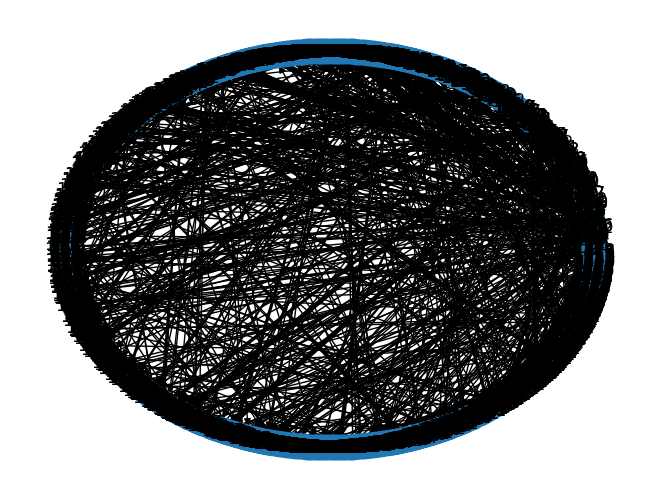

In [56]:
nx.draw_circular(G, with_labels=True)
import matplotlib.pyplot as plt
plt.show()